<a href="https://colab.research.google.com/github/abdullabasheer67/multivariate-stock-price-forecasting-lstm/blob/main/MULTIVARIATE_TIME_SERIES_FORECASTING_(STOCK_PREDICTION_)_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APPLE STOCK PREDICTION USING **LSTM**

In [22]:
#author : ABDULLA BASHEER
# we are using the apples stock price data from 1980 to around current time line

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [60]:
df = pd.read_csv('/content/AAPL.csv')

In [61]:
df.shape
# df.head()

(10836, 7)

# PREPROCESSING

In [62]:
# we want date as our index
#also we should do the preprocessing so lets start from there
#lets check if there is any null value in any column
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [63]:
#from the output we understand there are no null values
#now lets look into the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10836 entries, 0 to 10835
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10836 non-null  object 
 1   Open       10836 non-null  float64
 2   High       10836 non-null  float64
 3   Low        10836 non-null  float64
 4   Close      10836 non-null  float64
 5   Adj Close  10836 non-null  float64
 6   Volume     10836 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 592.7+ KB


In [64]:
#so since we want to index by date we have to CONVERT DATE into datetime data type
df['Date'] = pd.to_datetime(df['Date'])

In [65]:
#now lets see the change
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10836 entries, 0 to 10835
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10836 non-null  datetime64[ns]
 1   Open       10836 non-null  float64       
 2   High       10836 non-null  float64       
 3   Low        10836 non-null  float64       
 4   Close      10836 non-null  float64       
 5   Adj Close  10836 non-null  float64       
 6   Volume     10836 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 592.7 KB


In [66]:
#now we can convert date as our index
df.set_index('Date',inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10836 entries, 1980-12-12 to 2023-12-05
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10836 non-null  float64
 1   High       10836 non-null  float64
 2   Low        10836 non-null  float64
 3   Close      10836 non-null  float64
 4   Adj Close  10836 non-null  float64
 5   Volume     10836 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 592.6 KB


In [67]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099319,469033600
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094137,175884800
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087228,105728000
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089387,86441600
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091978,73449600


In [68]:
 # we cant use just minmax scaler for entire dataset as there will be dat leakage , but lets just scale and see how the data is so that we should decide on the train test data
 scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[df.columns])
#lets convert this array format to df format
df_scaled=pd.DataFrame(scaled_data,columns=df.columns,index=df.index)
#now here we changed format ,gave column names and index

In [69]:
df_scaled.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.000401,0.000400,0.000406,0.000403,0.000313,0.063198
1980-12-15,0.000370,0.000366,0.000372,0.000369,0.000287,0.023699
1980-12-16,0.000324,0.000321,0.000326,0.000324,0.000251,0.014246
1980-12-17,0.000336,0.000335,0.000340,0.000338,0.000262,0.011647
1980-12-18,0.000353,0.000352,0.000357,0.000355,0.000276,0.009897


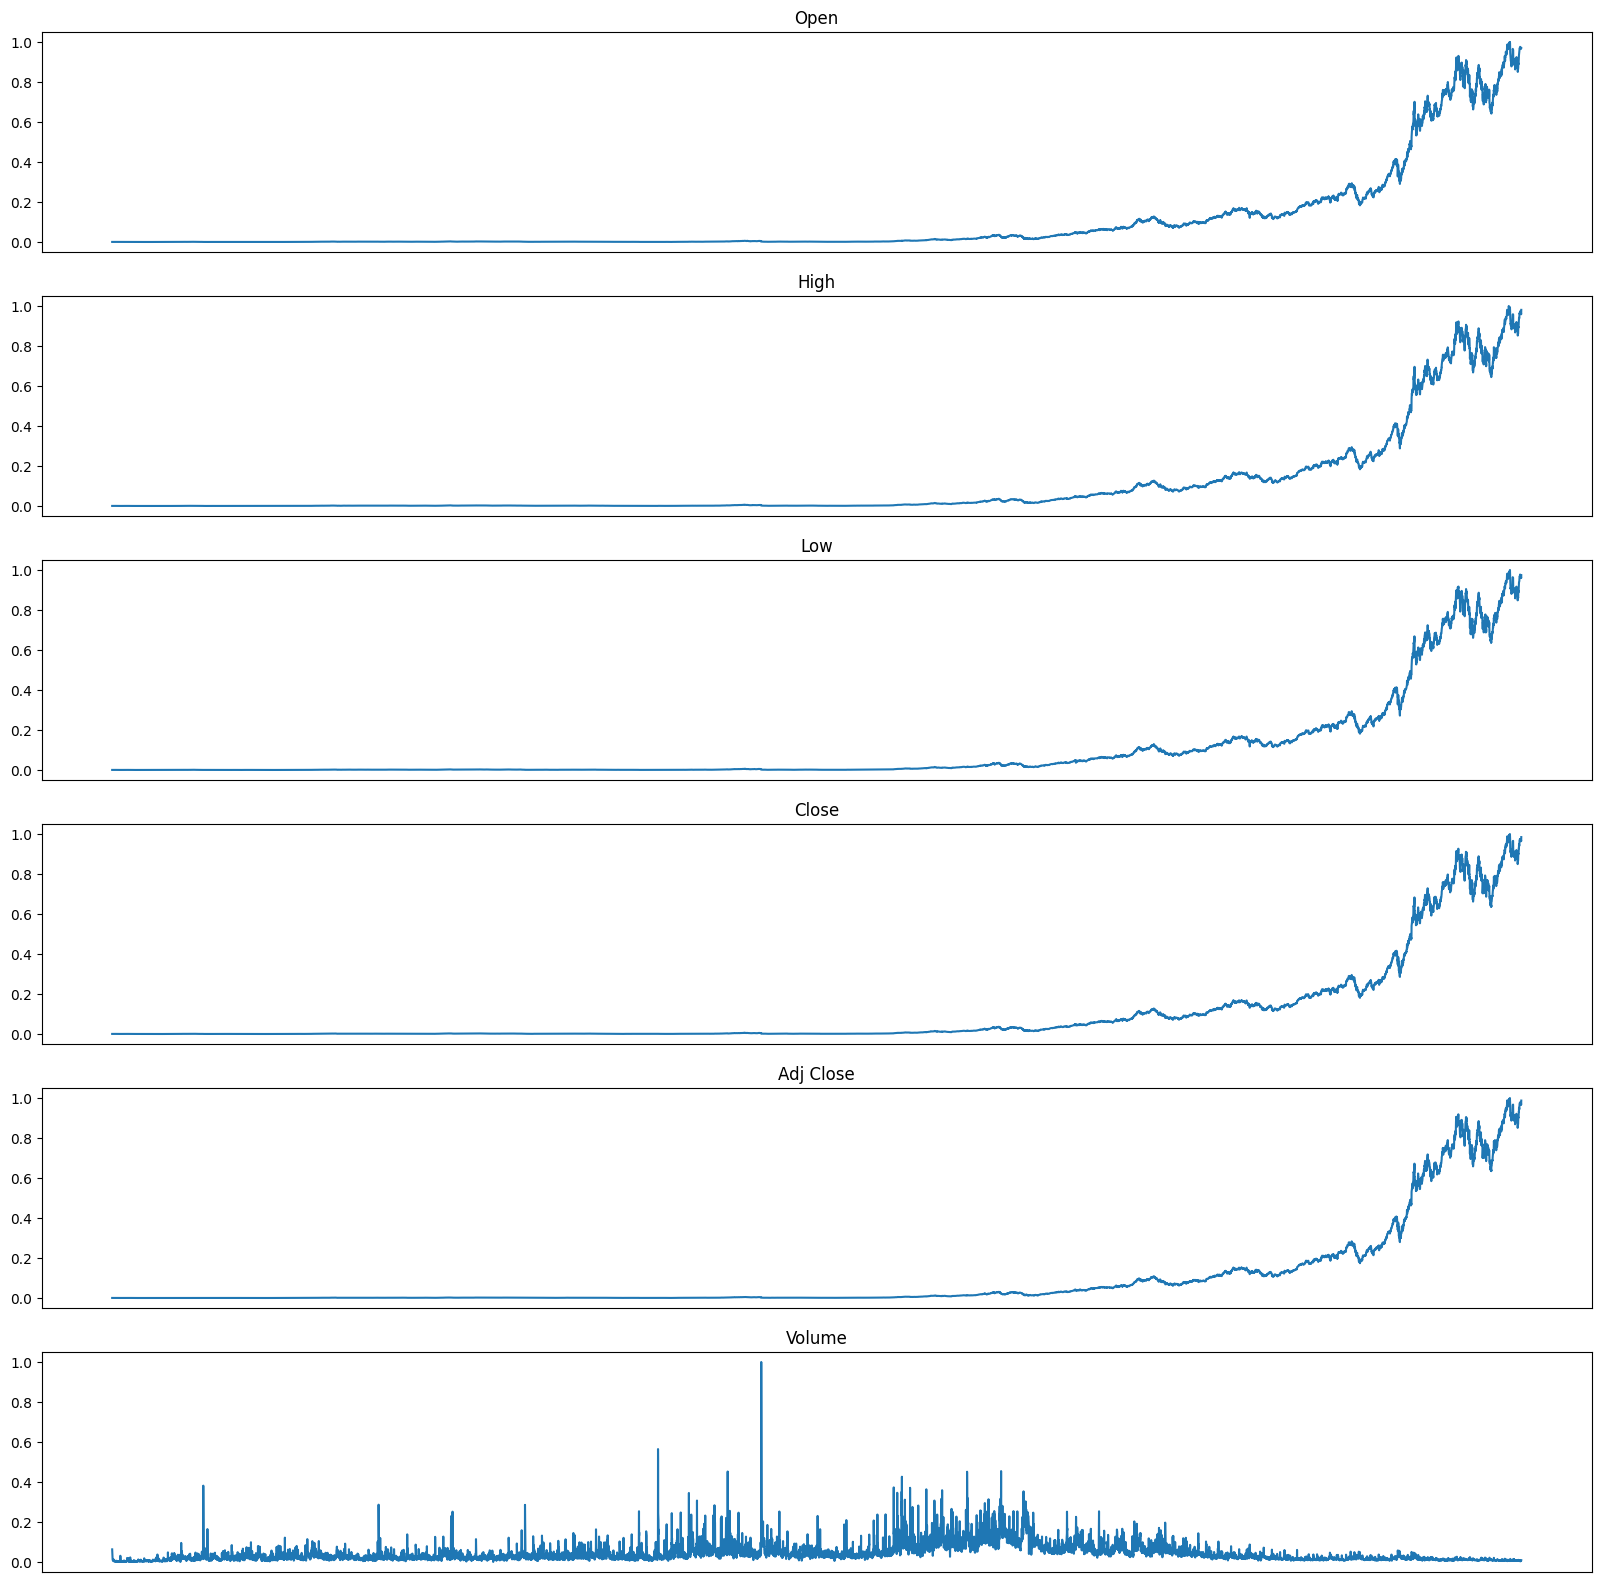

In [70]:
#FIRST lets set the fig size and number os subplots required
plt.rcParams['figure.figsize']=(20,20)
figure,axes = plt.subplots(6)
for ax,col in zip(axes,df_scaled.columns):
  ax.plot(df_scaled[col])
  ax.set_title(col)
  ax.axes.xaxis.set_visible(False)

In [71]:
#now we can see the dates have become the new index , now our next motive is to make sure the data is in ascending order because LSTM works with sequential data
df.sort_index(inplace=True)

In [72]:
# Chronological split (preserve time order)
#train_size = int(len(df) * 0.8)
#train_df = df.iloc[:train_size].copy()
#test_df  = df.iloc[train_size:].copy()

# Fit scaler on training data only
#scaler = MinMaxScaler()
#scaler.fit(train_df)

# Transform both sets
#train_scaled = scaler.transform(train_df)
#test_scaled  = scaler.transform(test_df)

# Convert back to DataFrames (optional, helps with sequence creation)
#train_scaled = pd.DataFrame(train_scaled, columns=df.columns, index=train_df.index)
#test_scaled  = pd.DataFrame(test_scaled,  columns=df.columns, index=test_df.index)
# Chronological split (preserve time order)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df  = df.iloc[train_size:].copy()

# Fit scaler on training data only
scaler = MinMaxScaler()
scaler.fit(train_df)

# --- DIAGNOSTIC PRINTS ---
print("Feature mins:", scaler.data_min_)
print("Feature maxs:", scaler.data_max_)
print("Feature names:", train_df.columns.tolist())
# -------------------------

# Transform both sets
train_scaled = scaler.transform(train_df)
test_scaled  = scaler.transform(test_df)

# Convert back to DataFrames (optional, helps with sequence creation)
train_scaled = pd.DataFrame(train_scaled, columns=df.columns, index=train_df.index)
test_scaled  = pd.DataFrame(test_scaled,  columns=df.columns, index=test_df.index)

Feature mins: [0.049665 0.049665 0.049107 0.049107 0.038    0.      ]
Feature maxs: [3.3235001e+01 3.3400002e+01 3.2792500e+01 3.3250000e+01 2.9880913e+01
 7.4216408e+09]
Feature names: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [73]:
window_size = 100
X_train, Y_train = create_sequence(train_scaled, window_size)
X_test,  Y_test  = create_sequence(test_scaled,  window_size)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape :", X_test.shape)
print("Y_test shape :", Y_test.shape)

X_train shape: (8568, 100, 6)
Y_train shape: (8568, 6)
X_test shape : (2068, 100, 6)
Y_test shape : (2068, 6)


CREATING THE SLIDING WINDOW SEQUENCES

In [74]:
#THIS APPROACH is only used while we are working with LSTM MODELS WORKING WITH time series forecating.
#Helps the model to learn from multiple slightly shifted sequences of the past data to predict the future data
def create_sequence(data,window_size):
    X=[]#append the sequence of data
    Y=[]#append the target data
    for i in range(window_size,len(data)):
        X.append(data.iloc[i-window_size:i].values)
        Y.append(data.iloc[i].values)
    return np.array(X),np.array(Y)

BUILDING LSTM MODEL

In [75]:
model=keras.Sequential([
    keras.layers.LSTM(units=80,return_sequences=True,input_shape=(X_train.shape[1],X_train.shape[2])),
    keras.layers.Dropout(0.2),#first layer
    keras.layers.LSTM(units=80,return_sequences=True,input_shape=(X_train.shape[1],X_train.shape[2])),
    keras.layers.Dropout(0.2),#second layer
    keras.layers.LSTM(units=80,return_sequences=False,input_shape=(X_train.shape[1],X_train.shape[2])),
    keras.layers.Dropout(0.2),#last layer so false
   keras.layers.Dense(Y_train.shape[1])
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [76]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),loss='mean_squared_error',metrics=['RootMeanSquaredError'])

EARLY STOPPING

In [77]:
early_stopping=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [81]:
LSTM_MODEL=model.fit(X_train,Y_train,validation_split=0.2,epochs=100,batch_size=64,callbacks=[early_stopping])

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 49s 455ms/step - RootMeanSquaredError: 0.0161 - loss: 2.6185e-04 - val_RootMeanSquaredError: 0.0828 - val_loss: 0.0069
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 77s 403ms/step - RootMeanSquaredError: 0.0149 - loss: 2.2374e-04 - val_RootMeanSquaredError: 0.0778 - val_loss: 0.0061
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 45s 414ms/step - RootMeanSquaredError: 0.0161 - loss: 2.5914e-04 - val_RootMeanSquaredError: 0.0877 - val_loss: 0.0077
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 44s 409ms/step - RootMeanSquaredError: 0.0144 - loss: 2.0823e-04 - val_RootMeanSquaredError: 0.0505 - val_loss: 0.0026
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 81s 401ms/step - RootMeanSquaredError: 0.0166 - loss: 2.8210e-04 - val_RootMeanSquaredError: 0.0371 - val_loss: 0.0014
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 84s 419ms/step - RootMeanSquaredError: 0.0141 - loss: 1.9839e-04 - val_RootMeanSquaredError: 0.0525 - val_loss: 0.0028
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━

In [82]:
predictions=model.predict(X_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step


# FORECASTING

In [83]:
#WE HAVE NORMALIZED OUR VALUES SO WE SHOULD CONVERT THEM BACK, INVERSE SCALING
predictions[:5]

array([[ 0.86656374,  0.85908633,  0.8195906 ,  0.8622855 ,  0.79553354,
         0.00239322],
       [ 0.8679273 ,  0.8602459 ,  0.82070184,  0.86360216,  0.7965921 ,
         0.00796452],
       [ 0.869567  ,  0.86192256,  0.8223318 ,  0.8653753 ,  0.79815054,
         0.00097765],
       [ 0.8697008 ,  0.8618535 ,  0.8223103 ,  0.86541975,  0.7980678 ,
         0.00342619],
       [ 0.86992794,  0.8620549 ,  0.8225242 ,  0.8657196 ,  0.7982714 ,
        -0.00141062]], dtype=float32)

In [84]:
predictions=scaler.inverse_transform(predictions)
Y_test=scaler.inverse_transform(Y_test)
# Clip predictions to [0, 1] to avoid extreme values after inverse transform
#predictions_clipped = np.clip(predictions, 0, 1)

# Inverse transform
#predictions = scaler.inverse_transform(predictions_clipped)
#Y_test = scaler.inverse_transform(Y_test)

In [85]:
predictions[:5]

array([[ 2.8806875e+01,  2.8700483e+01,  2.6885286e+01,  2.8677755e+01,
         2.3779037e+01,  1.7761616e+07],
       [ 2.8852125e+01,  2.8739155e+01,  2.6921671e+01,  2.8721470e+01,
         2.3810629e+01,  5.9109820e+07],
       [ 2.8906538e+01,  2.8795073e+01,  2.6975040e+01,  2.8780338e+01,
         2.3857138e+01,  7.2557690e+06],
       [ 2.8910978e+01,  2.8792768e+01,  2.6974339e+01,  2.8781815e+01,
         2.3854668e+01,  2.5427982e+07],
       [ 2.8918516e+01,  2.8799484e+01,  2.6981340e+01,  2.8791771e+01,
         2.3860744e+01, -1.0469103e+07]], dtype=float32)

plotting

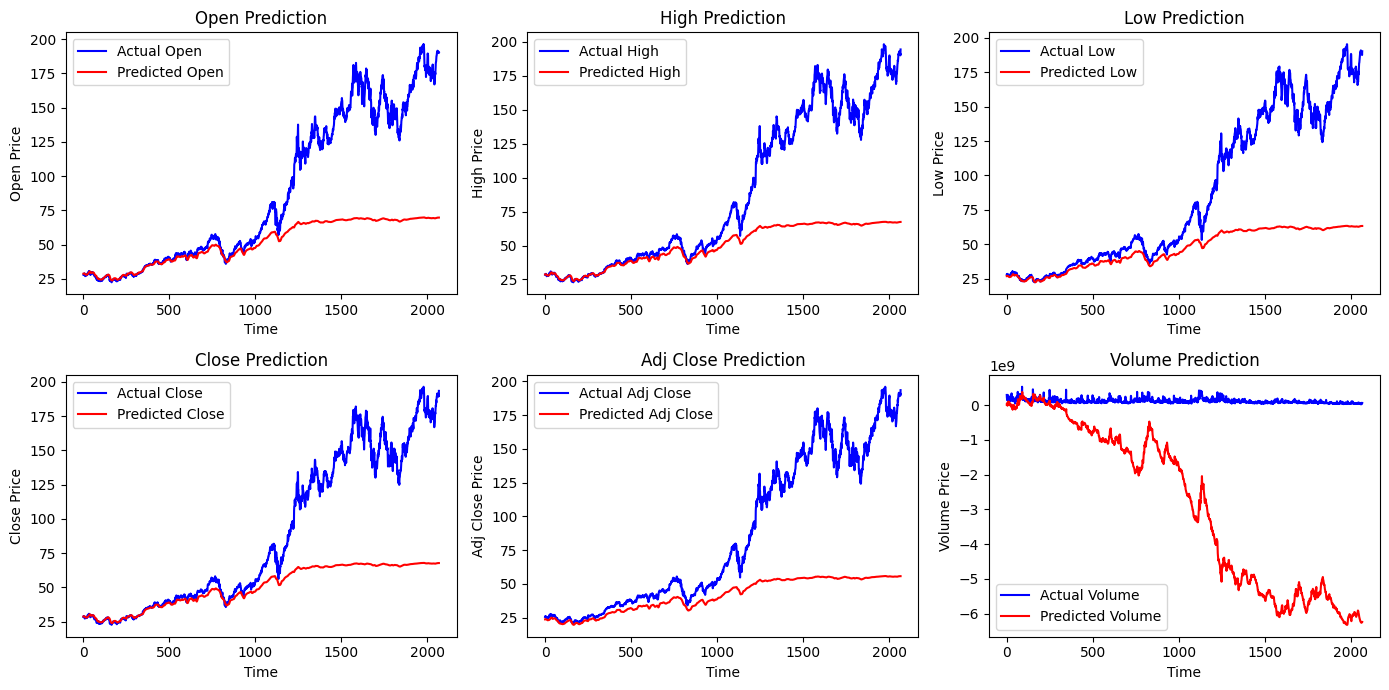

In [86]:
plt.figure(figsize=(14, 7))
for i, col in enumerate(df.columns):   # use original column names
    plt.subplot(2, 3, i+1)
    plt.plot(Y_test[:, i], color='blue', label=f'Actual {col}')
    plt.plot(predictions[:, i], color='red', label=f'Predicted {col}')
    plt.title(f'{col} Prediction')
    plt.xlabel('Time')
    plt.ylabel(f'{col} Price')
    plt.legend()
plt.tight_layout()
plt.show()

Here you see that there is a huge variation between actual and predicted , this is bcz the data we used to train is almost flat to its 70 or 80 percent and the testdata we provided has a lot of ups and downs , so when selecting train data , choose a 30 percent from front, 30 from middle and 30 from last so the model gets an overall idea, the volume had to be scaled differentl.

In [49]:
#except for that our model learned and predicted something which is our aim right now, also we have to detrend , which is a core step in time series .
actual = Y_test[:,3]
predicted = predictions[:,3]
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 62.171098916810614
RMSE: 81.61577843189269
MAPE: 57.94782610237863
